# Corn conveyor : custom category (v0.2 extension)

Extending v1.0 to a self-recorded video of popping corn spread on the floor, with grape and walnut chunks introduced as foreign objects. This notebook reproduces the `corn_comparison.png` figure shown in the README.

**Method setup.** Same frozen ResNet-18 layer3 feature extractor as the MVTec notebooks. Both anomaly methods (per-pixel Gaussian and memory-bank kNN) are fit on 32 clean training frames sampled from t=1s to 17s of `data/conveyor_corn.mp4`, then scored on a test frame containing both a grape and a walnut chunk.

References: Defard et al., *PaDiM*, ICPR 2020; Roth et al., *PatchCore*, CVPR 2022.

In [1]:
import sys
sys.path.append("..")   # so we can import from src/

import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image

from src.dataset import MVTecDataset, IMAGENET_MEAN, IMAGENET_STD
from src.features import FeatureExtractor
from src.methods import GaussianAD, NearestNeighborAD
from src.visualize import upsample_and_smooth, plot_method_comparison

CATEGORY = "corn"
DATA_ROOT = "../data/custom"
IMAGE_SIZE = 224
BATCH_SIZE = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## Data

The `corn` category has 32 training images (all `good`, sampled at 0.5s intervals from the clean portion of the video) and a test set of 44 frames: 6 held-out clean frames and 38 frames containing foreign objects (grape, walnut chunks, or both).

Full-frame square resize (not center crop): the phone recorded portrait 1080x1920, and the anomaly can appear anywhere in the frame. Aspect distortion is uniform between train and test, so the anomaly signal is preserved.

In [2]:
tfm = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = MVTecDataset(DATA_ROOT, CATEGORY, is_train=True, transform=tfm)
test_ds  = MVTecDataset(DATA_ROOT, CATEGORY, is_train=False, transform=tfm)

print(f"train : {len(train_ds)} images (all good)")
print(f"test  : {len(test_ds)} images across defect types: {test_ds.defect_types()}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)

train : 32 images (all good)
test  : 44 images across defect types: ['foreign_object', 'good']


## Feature extractor

Pretrained ResNet-18, truncated at `layer3`. Output shape is `(256, 14, 14)` per image at 224x224 input. All parameters frozen.

In [3]:
extractor = FeatureExtractor(stop_layer="layer3").to(device)
print(f"output channels: {extractor.num_channels}")
print(f"trainable params: {sum(p.numel() for p in extractor.parameters() if p.requires_grad)}")

output channels: 256
trainable params: 0


## Fit both methods

**GaussianAD**: per-pixel diagonal Gaussian over the 256 layer3 channels. With only 32 training samples the covariance estimate is noisy, but the signal from a fully out-of-distribution object (grape, walnut) is far larger than the noise.

**NearestNeighborAD**: memory bank of all training feature vectors, k=3 mean L2 distance. Position-agnostic, which matters here because the camera slides over the corn so a given pixel location does not mean the same thing across frames.

In [4]:
%%time
gad = GaussianAD(diag_only=True)
gad.fit(extractor, train_loader, device)
print("GaussianAD mean shape :", gad.mean.shape)

GaussianAD mean shape : torch.Size([256, 14, 14])
CPU times: user 11.7 s, sys: 373 ms, total: 12 s
Wall time: 3.01 s


In [5]:
%%time
knn = NearestNeighborAD(k=3, max_bank_size=20_000)
knn.fit(extractor, train_loader, device)
print("KNN bank shape :", knn.bank.shape)

KNN bank shape : torch.Size([6272, 256])
CPU times: user 12.5 s, sys: 73.1 ms, total: 12.6 s
Wall time: 2.61 s


## Score and visualize a test frame

Frame `anomaly_022.png` contains a grape (center-right) and a walnut chunk (bottom-left). Score it with both methods, upsample to 224x224, smooth, overlay. Save the comparison figure to `results/heatmaps/corn_comparison.png`.

In [6]:
TEST_FRAME = "../data/custom/corn/test/foreign_object/anomaly_032.png"

img_pil = Image.open(TEST_FRAME).convert("RGB")
img_tensor = tfm(img_pil)
print(f"test frame: {TEST_FRAME}")
print(f"tensor shape: {tuple(img_tensor.shape)}")

with torch.inference_mode():
    fmap = extractor(img_tensor.unsqueeze(0).to(device))[0]

gad_score = gad.score(fmap)
knn_score = knn.score(fmap)
print(f"GaussianAD score  min={gad_score.min():.3f}  max={gad_score.max():.3f}")
print(f"KNN score         min={knn_score.min():.3f}  max={knn_score.max():.3f}")

test frame: ../data/custom/corn/test/foreign_object/anomaly_032.png
tensor shape: (3, 224, 224)
GaussianAD score  min=9.511  max=39.297
KNN score         min=1.259  max=3.105


saved: ../results/heatmaps/corn_comparison.png


/tmp/ipykernel_46071/395038109.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


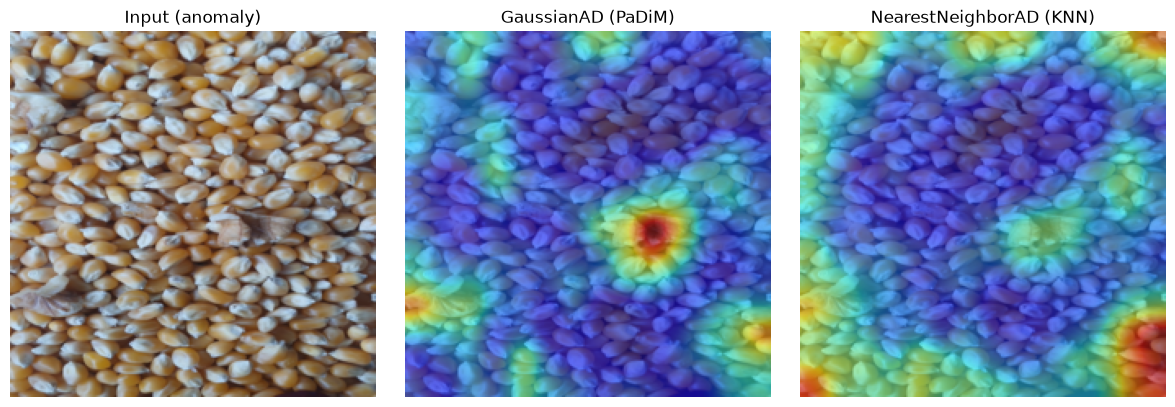

In [7]:
gad_heat = upsample_and_smooth(gad_score, out_size=IMAGE_SIZE, sigma=4.0)
knn_heat = upsample_and_smooth(knn_score, out_size=IMAGE_SIZE, sigma=4.0)

heatmaps = {
    "GaussianAD (PaDiM)": gad_heat,
    "NearestNeighborAD (KNN)": knn_heat,
}
fig = plot_method_comparison(img_tensor, heatmaps, label=1, alpha=0.5)

out_path = "../results/heatmaps/corn_comparison.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
print(f"saved: {out_path}")
fig.show()

## Analysis

Both methods localize the grape sharply and agree strongly. The walnut chunk in the bottom-left also registers on both heatmaps. Unlike the MVTec `grid` and `pill` cases, the two methods do not disagree here.

The reason is regime. MVTec defects are subtle in-distribution perturbations (scratches on a surface, missing color specks) where the choice of distance shapes the outcome. A per-location Gaussian excels on repetitive registered textures (`grid`), a position-agnostic bank excels on multi-modal objects with pose variation (`pill`). Foreign objects on corn are qualitatively different: they are entirely out-of-distribution in feature space, so any reasonable distance separates them cleanly.

Practical read: on subtle industrial defects, method choice matters. On foreign-object contamination in bulk material, both methods just work. The interesting engineering question shifts to the video pipeline (temporal smoothing, persistence gating, throughput), not to the anomaly method itself.

## Threshold calibration for the video pipeline

The video pipeline needs a numeric threshold to decide when to fire the "ANOMALY" banner. We calibrate on the 6 held-out clean test frames: score each with GaussianAD, take the maximum per frame, and set the threshold above the highest observed clean max.

GaussianAD is the method used in the video (rather than KNN) because on this data the position-locked per-cell Gaussians detect the walnut chunks that KNN misses (visible in the comparison figure above). Same disagreement pattern as MVTec `grid` vs `pill`.

Threshold generalizes to any foreign object (rice, almond) because it only uses knowledge of what clean looks like, not what anomalies look like.

In [8]:
import numpy as np

clean_scores_gad = []
for i in range(len(test_ds)):
    img, lbl = test_ds[i]
    if lbl != 0:
        continue
    with torch.inference_mode():
        fmap = extractor(img.unsqueeze(0).to(device))[0]
    score = gad.score(fmap)
    clean_scores_gad.append(float(score.max().item()))

print(f"Clean frames scored: {len(clean_scores_gad)}")
for s in clean_scores_gad:
    print(f"  max={s:.3f}")
print(f"\nmin    : {min(clean_scores_gad):.3f}")
print(f"median : {np.median(clean_scores_gad):.3f}")
print(f"max    : {max(clean_scores_gad):.3f}")

Clean frames scored: 6
  max=16.385
  max=19.583
  max=25.126
  max=23.065
  max=23.910
  max=22.919

min    : 16.385
median : 22.992
max    : 25.126


In [9]:
SAFETY_MARGIN = 1.10
threshold_gad = float(max(clean_scores_gad) * SAFETY_MARGIN)
print(f"threshold = max(clean) * {SAFETY_MARGIN} = {threshold_gad:.3f}")

state = {
    "method": "gaussian",
    "gad_mean": gad.mean,
    "gad_inv_cov": gad.inv_cov,
    "gad_diag_only": gad.diag_only,
    "threshold": threshold_gad,
    "image_size": IMAGE_SIZE,
    "clean_scores": clean_scores_gad,
}
torch.save(state, "../results/corn_model.pt")
print("saved: results/corn_model.pt (GaussianAD)")

threshold = max(clean) * 1.1 = 27.639
saved: results/corn_model.pt (GaussianAD)
